In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
# Define predictors and response variables
X = df[['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
       'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution']]
y = df["Heating Load"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data  
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [6]:
# Train OLS regression model
ols_model = LinearRegression()
# Fit the model on the training data
ols_model.fit(X_train_scaled, y_train)    
# Predict on the test set and calculate MSE  
mse_ols = mean_squared_error(y_test, ols_model.predict(X_test_scaled))  

print(f"OLS Test MSE: {mse_ols:.4f}")

OLS Test MSE: 8.8395


In [7]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [8]:
# Define 100 lambda values
lambdas = np.logspace(-4, 4, 100)

# Fit RidgeCV with 10-fold CV 
ridge_cv = RidgeCV(alphas= lambdas, cv= 10, scoring='neg_mean_squared_error')

## Fit on scaled training data
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best lambda: { ridge_cv.alpha_:.4f}")

# OLS and Ridge Table
coef_table = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols_model.coef_,      
    'Ridge Coefficient': ridge_cv.coef_
})
coef_table



Best lambda: 0.2057


,Feature,OLS Coefficient,Ridge Coefficient
0,Relative Compactness,-6.686924,-6.352418
1,Surface Area,-3.701472,-3.474392
2,Wall Area,0.761142,0.816587
3,Roof Area,-3.992429,-3.797180
4,Overall Height,7.216818,7.306373
5,Orientation,-0.026067,-0.025299
6,Glazing Area,2.670032,2.670852
7,Glazing Area Distribution,0.356042,0.356417


In [9]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

The penalty term is doing its job because most coefficents are slightly smaller in magnitude. The changes are small because lambda is 0.2057 is very small, meaning the penaltiy is weak and Ridge is close to OLS. 

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [10]:
# Use fitted ridge_cv to predict on test set
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
# Calculate MSE on test set
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

print(f" Ridge CV Test MSE: {mse_rcv:.4f}")



 Ridge CV Test MSE: 8.8440


In [11]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

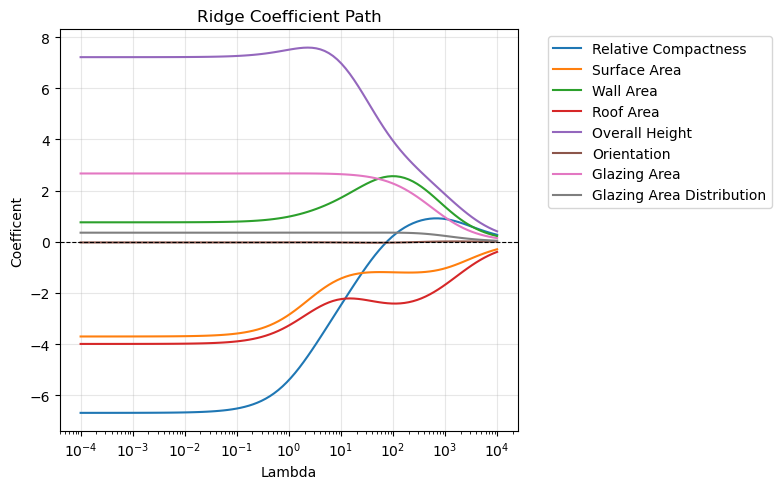

In [12]:
# Store coefficents for each lambda
coefs = []

for alpha in lambdas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)
    
coefs = np.array(coefs) 

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for i, name in enumerate(feature_names):
    plt.plot(lambdas, coefs[:, i], label=name)
    
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficent')
plt.title('Ridge Coefficient Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Overall Height and Glazing Area appear to be most important coefficents because they resist shrinkage the longest, meaning they have the strongest relationship with heating laod. 

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [13]:
# Fit LassoCV with 100 lambda values and 10-fold cross-validation
lasso_cv = LassoCV(alphas= lambdas, cv= 10)

# Fit on scaled training data
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best lambda: {lasso_cv.alpha_:.4f}")

# Build comparison table of OLS vs Lasso coefficents 
coef_table = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': ols_model.coef_,      
    'Lasso  Coefficient': lasso_cv.coef_
})
coef_table


Best lambda: 0.0016


,Feature,OLS Coefficient,Lasso Coefficient
0,Relative Compactness,-6.686924,-6.418330
1,Surface Area,-3.701472,-6.231035
2,Wall Area,0.761142,2.152524
3,Roof Area,-3.992429,-1.044324
4,Overall Height,7.216818,7.309160
5,Orientation,-0.026067,-0.023593
6,Glazing Area,2.670032,2.670194
7,Glazing Area Distribution,0.356042,0.354971


In [14]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Neither method zeroed out coefficents here (lambda too small), Lasso changed some coefficents more dramatically than Ridge. Ridge shrinkage was more stable across all features. 

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [15]:
# Use fitted lasso_cv to predict on test set
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
# Calculate MSE on test set 
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

print(f" Lasso CV Test MSE: {mse_lcv:.4f}")


 Lasso CV Test MSE: 8.8416


In [16]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [17]:
# Build summary table comparing Test MSE across all three models 
mse_table = pd.DataFrame({
    'Model': ['OLS', 'Ridge CV', 'Lasso CV'], 
    'Tuning Parameter': [None, ridge_cv.alpha_, lasso_cv.alpha_],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv]
})
mse_table

,Model,Tuning Parameter,Test MSE
0,OLS,NaN,8.839503
1,Ridge CV,0.205651,8.843961
2,Lasso CV,0.001630,8.841571


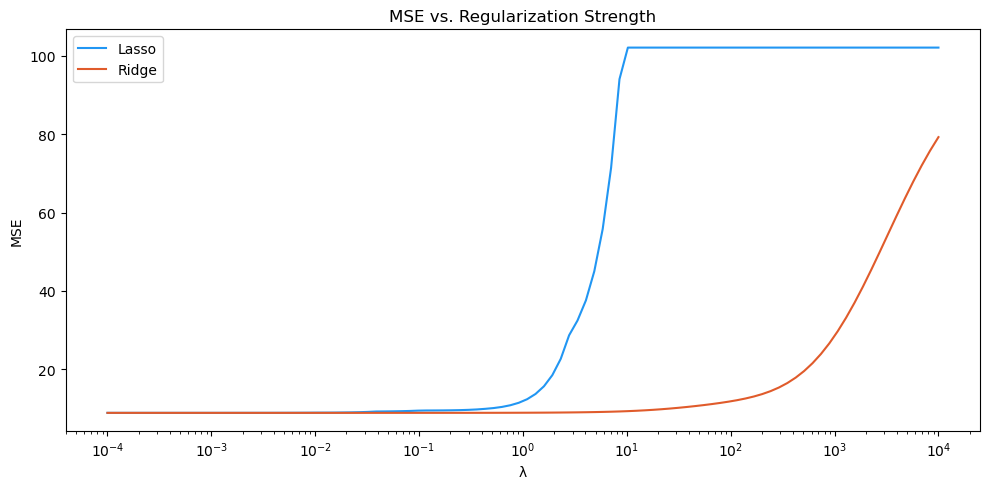

In [18]:
# Visualize lambdas against MSE for Lasso and Ridge
# Store MSE for each lambda
mse_lasso = []
mse_ridge = []

# Loos over each lambda, fit both models, and record test MSE
for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10000)
    ridge = Ridge(alpha=lam)

    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))

# Plot MSE vs lambda for both models
plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='#2196F3')
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

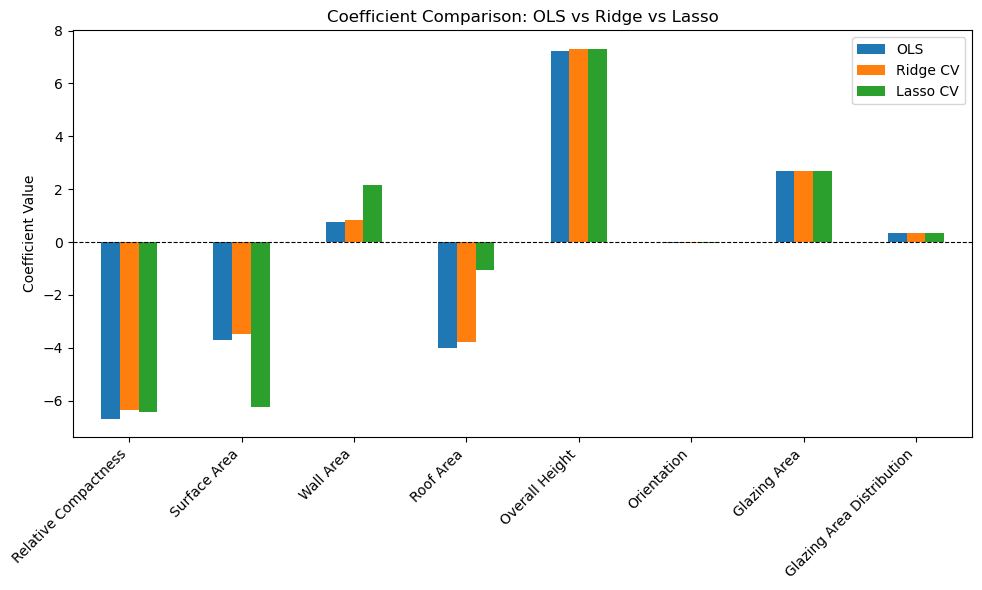

In [19]:
# Build dataframe of coefficients for all three models
coef_compare = pd.DataFrame({
    'OLS': ols_model.coef_,
    'Ridge CV': ridge_cv.coef_,
    'Lasso CV': lasso_cv.coef_
}, index=feature_names)

# Plot grouped bar chart
coef_compare.plot.bar(figsize=(10, 6))
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Coefficient Comparison: OLS vs Ridge vs Lasso')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


> **Q4: Which model would you pick for this dataset? Why?**

I would pick Ridge because it seems to be more stable than Lasso, it tolerates higher lambda without sacrificing much accuracy since all 8 features are useful zeroing them out will hurt interprtability. All three models have nearly identical MSE(~8.84) so regularization isnt much helpful, but Ridge is still a better choice than OLS if the data were noisier. 

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [20]:
# Fit PCA on scaled training data using all 8 components
pca_full = PCA(n_components=8)
pca_full.fit(X_train_scaled)    

# Store individual and cumulative explained variance 
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
explained_var

array([4.62904753e-01, 1.56318178e-01, 1.49748425e-01, 1.24314772e-01,
       9.96632239e-02, 6.47726840e-03, 5.73378958e-04, 1.09797370e-32])

In [21]:
# Print variance table
variance_table = pd.DataFrame({
    'Component': range(1, 9),
    'Explained Variance (%)': explained_var,
    'Cumulative Variance (%)': cumulative_var
})
variance_table

,Component,Explained Variance (%),Cumulative Variance (%)
0,1,4.629048e-01,0.462905
1,2,1.563182e-01,0.619223
2,3,1.497484e-01,0.768971
3,4,1.243148e-01,0.893286
4,5,9.966322e-02,0.992949
5,6,6.477268e-03,0.999427
6,7,5.733790e-04,1.000000
7,8,1.097974e-32,1.000000


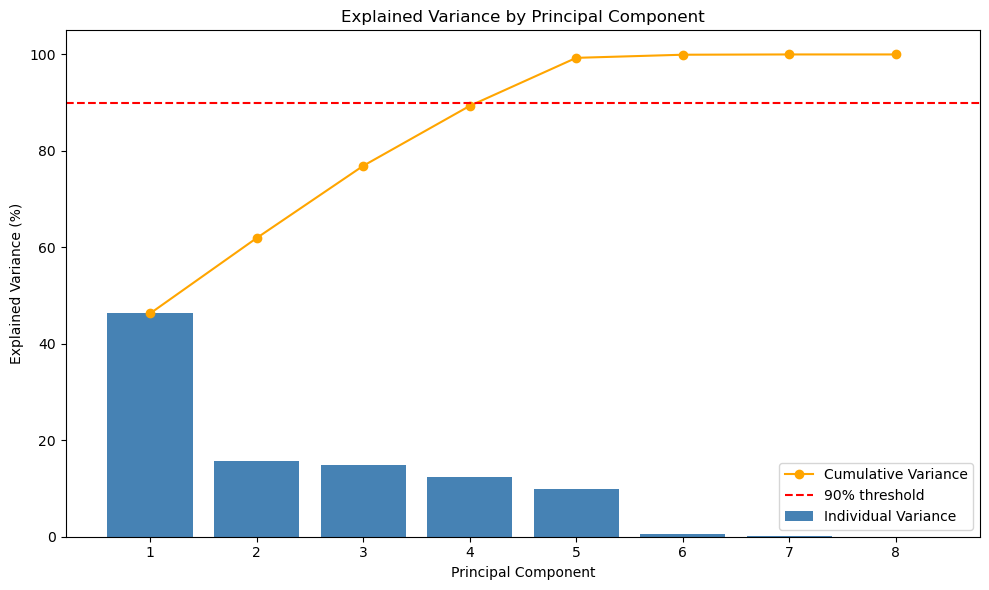

In [22]:
# Plot individual and cumulative explained variance
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for individual explained variance
ax1.bar(range(1, 9), explained_var *100, color='steelblue', label='Individual Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')

# Line plot for cumulative variance
ax1.plot(range(1, 9), cumulative_var * 100, color='orange', marker='o', label='Cumulative Variance')
ax1.axhline(y=90, color='red', linestyle='--', label='90% threshold')

ax1.set_title('Explained Variance by Principal Component')
ax1.legend()
plt.tight_layout()
plt.show()

In [23]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes 4 principle components to explain at least 90% of the variance in the features. The cumulative varaince reaches ~90% at PC4, with PC1 alone explaing ~47%. 

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [26]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = 4

# Fit PCA with best_k components
pca_final = PCA(n_components=best_k)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

# Fit OLS on the project data
ols_pcr = LinearRegression()
ols_pcr.fit(X_train_pca, y_train)

# Predict and calculate MSE
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
print(f"PCR Test MSE: {mse_pcr:.4f}")


PCR Test MSE: 14.5239


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

I pciked 4 for the value of k because it explained ~90% of variance, but the heigher MSE suggest the dropped componenets still containted predictive ifnromation. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [27]:
# Summary table comparing all four models
summary_table = pd.DataFrame({
    'Model': ['OLS', 'Ridge CV', 'Lasso CV', 'PCR'], 
    'Tuning Parameter': [None, ridge_cv.alpha_, lasso_cv.alpha_, best_k],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv, mse_pcr]
})
summary_table

,Model,Tuning Parameter,Test MSE
0,OLS,NaN,8.839503
1,Ridge CV,0.205651,8.843961
2,Lasso CV,0.001630,8.841571
3,PCR,4.000000,14.523853


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

OLS, Ridge CV, and Lasso CV didnt perform much different from eachother are all have a test MSE of ~8.84, meaning regularication didint help much. PCR perform the worst (14.52), the assumptions that high-variance directions predict the response didnt hold here. The patter suggest all 8 original features carry useful signal, and rotating them into PCs lost some predictive information. 

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [28]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!